**Install Required Libraries**

In [1]:
pip install yfinance

  Using cached markdown_it_py-4.0.0-py3-none-any.whl.metadata (7.3 kB)
  Using cached mdurl-0.1.2-py3-none-any.whl.metadata (1.6 kB)
   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ------ --------------------------------- 0.3/1.7 MB ? eta -:--:--
   ------ --------------------------------- 0.3/1.7 MB ? eta -:--:--
   ------ --------------------------------- 0.3/1.7 MB ? eta -:--:--
   ------------ --------------------------- 0.5/1.7 MB 522.3 kB/s eta 0:00:03
   ------------ --------------------------- 0.5/1.7 MB 522.3 kB/s eta 0:00:03
   ------------------ --------------------- 0.8/1.7 MB 491.1 kB/s eta 0:00:02
   ------------------------- -------------- 1.0/1.7 MB 613.0 kB/s eta 0:00:02
   ------------------------- -------------- 1.0/1.7 MB 613.0 kB/s eta 0:00:02
   ------------------------- -------------- 1.0/1.7 MB 613.0 kB/s eta 0:00:02
   ------------------------------- -------- 1.3/1.7 MB


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: C:\Users\hi\AppData\Local\Programs\Python\Python313\python.exe -m pip install --upgrade pip


**Import Libraries**

In [2]:
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

**Load Stock Data**

In [3]:
stock_data = yf.download("AAPL", start="2020-01-01", end="2024-01-01")

stock_data.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2020-01-02,72.400528,72.460791,71.156689,71.409793,135480400
2020-01-03,71.696632,72.455950,71.472454,71.629138,146322800
2020-01-06,72.267914,72.306483,70.568488,70.819186,118387200
2020-01-07,71.928040,72.533080,71.708680,72.277563,108872000
2020-01-08,73.085106,73.386423,71.631552,71.631552,132079200


**Basic Inspection**

In [4]:
print(stock_data.shape)

stock_data.info()

stock_data.describe()

(1006, 5)
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1006 entries, 2020-01-02 to 2023-12-29
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   (Close, AAPL)   1006 non-null   float64
 1   (High, AAPL)    1006 non-null   float64
 2   (Low, AAPL)     1006 non-null   float64
 3   (Open, AAPL)    1006 non-null   float64
 4   (Volume, AAPL)  1006 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 47.2 KB


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
count,1006.000000,1006.000000,1006.000000,1006.000000,1.006000e+03
mean,137.957993,139.439050,136.328683,137.827953,9.895373e+07
std,33.357829,33.477922,33.218686,33.351565,5.439610e+07
min,54.213615,55.211532,51.372095,55.110049,2.404830e+07
25%,120.397034,121.638025,118.864121,120.502576,6.407675e+07
50%,142.816368,144.390277,141.154853,142.666133,8.467540e+07
75%,163.195023,165.471060,161.941430,163.462820,1.155069e+08
max,196.073090,197.567559,194.974519,195.984019,4.265100e+08


**Select Features and Target**

In [5]:
X = stock_data[['Open', 'High', 'Low', 'Volume']]

y = stock_data['Close']

**Train-Test Split**

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

**Train Model**

In [7]:
model = LinearRegression()

model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


**Make Predictions**

In [8]:
predictions = model.predict(X_test)

predictions[:5]

array([[177.35554552],
       [137.76965908],
       [146.29068976],
       [169.43654759],
       [126.89254614]])

**Evaluate Model**

In [9]:
mse = mean_squared_error(y_test, predictions)

print("Mean Squared Error:", mse)

Mean Squared Error: 0.9014439386083781


**Plot Actual vs Predicted Prices**

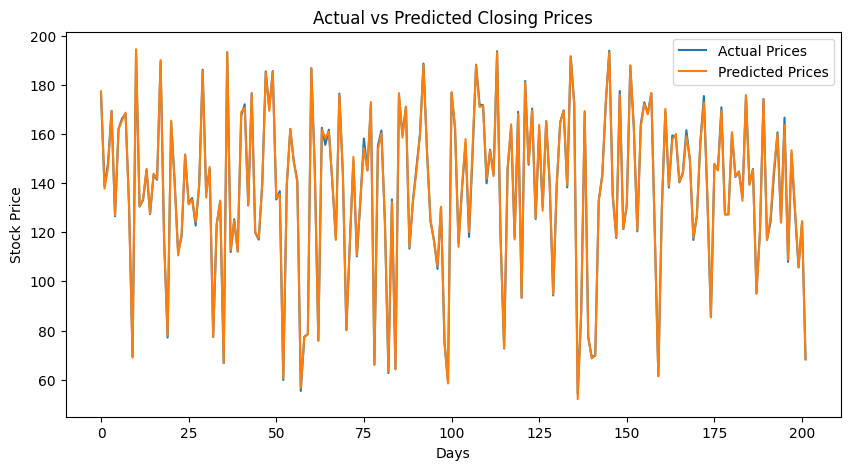

In [10]:
plt.figure(figsize=(10,5))

plt.plot(y_test.values, label='Actual Prices')

plt.plot(predictions, label='Predicted Prices')

plt.legend()

plt.title("Actual vs Predicted Closing Prices")

plt.xlabel("Days")

plt.ylabel("Stock Price")

plt.show()

**Observations**

- The predicted stock prices closely follow the actual stock prices.
- The Linear Regression model successfully captured the overall market trend.
- Small differences exist because stock prices are highly volatile.
- The model performs reasonably well for short-term prediction.

**Conclusion**

In this project, we used historical Apple stock data to predict closing prices using a Linear Regression model.

The model showed good performance as the predicted values were very close to actual stock prices. This project demonstrates how machine learning can be applied to financial forecasting and trend analysis.